# Open-Source Price Prediction Model (Week 7)

Inference-only price prediction using **at least 3 open-source models** via Ollama, reusing the Week 7 data and prompt format. No fine-tuning required.

**Models used:**
1. **gpt-oss:20b** (Ollama)
2. **llama3.2:3b** (Ollama) – same family as Week 7 base
3. **qwen2.5:7b** (Ollama)

**Prerequisites:**
- Ollama installed and running (`ollama serve`)
- Models pulled: `ollama pull gpt-oss:20b`, `ollama pull llama3.2:3b`, `ollama pull qwen2.5:7b`
- `HF_TOKEN` in env or `.env` for loading the dataset from HuggingFace

For **fine-tuning** these same models and then running the same price prediction evaluation, see `price_prediction_finetuned.ipynb`.

In [3]:
import os
import re
import math
import sys
from pathlib import Path

from dotenv import load_dotenv
from huggingface_hub import login
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

# Ensure week7/pricer is importable (run from repo root or week7)
for d in [Path.cwd(), Path.cwd() / "week7"]:
    if d.exists() and (d / "pricer" / "items.py").exists():
        if str(d) not in sys.path:
            sys.path.insert(0, str(d))
        break

from pricer.items import Item

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [4]:
load_dotenv(override=True)
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(hf_token, add_to_git_credential=True)
else:
    print("HF_TOKEN not set; HuggingFace login skipped. Set it to load the dataset.")

python(15478) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(15479) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(15482) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Data and prompts (reuse Day 2)

In [5]:
LITE_MODE = True  # Use items_lite for faster runs; set False for items_full
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
print(f"Loaded {len(train):,} train, {len(val):,} val, {len(test):,} test items")

python(15605) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(15606) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loaded 20,000 train, 1,000 val, 1,000 test items


In [6]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"
CUTOFF = 110

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, do_round=False)

print("Test prompt example:", repr(test[0].test_prompt()[:120]) + "...")

  0%|          | 0/1000 [00:00<?, ?it/s]

Test prompt example: 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBran'...


## Inference and price parsing

In [7]:
def extract_price(text: str):
    """Extract the first valid float from the model reply."""
    if not text or not text.strip():
        return None
    cleaned = text.replace(",", "").strip()
    match = re.search(r"\d+(?:\.\d+)?", cleaned)
    return float(match.group(0)) if match else None

In [8]:
from openai import OpenAI

OLLAMA_BASE = "http://localhost:11434/v1"
ollama_client = OpenAI(base_url=OLLAMA_BASE, api_key="ollama")


def predict_price(item: Item, model_name: str, client: OpenAI | None = None) -> float | None:
    """Call Ollama with item.test_prompt() and return parsed price."""
    client = client or ollama_client
    prompt = item.test_prompt()
    try:
        r = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=50,
        )
        content = (r.choices[0].message.content or "").strip()
        return extract_price(content)
    except Exception as e:
        print(f"Error ({model_name}): {e}")
        return None

## Model list (3+ open-source, including gpt-oss:20b)

In [9]:
OPEN_SOURCE_MODELS = [
    # "gpt-oss:20b",
    "llama3.2",
    "qwen3-vl:4b",
]
EVAL_SIZE = 100  # Number of test items per model (increase for full eval)

## Evaluation: MAE, RMSLE, and Tester-style chart

In [10]:
GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red": RED, "orange": YELLOW, "green": GREEN}


def color_for(error: float, truth: float) -> str:
    if error < 40 or (truth and error / truth < 0.2):
        return "green"
    if error < 80 or (truth and error / truth < 0.4):
        return "orange"
    return "red"


def evaluate_model(
    model_name: str,
    data: list,
    size: int = 100,
    client: OpenAI | None = None,
):
    """Run predictor on `size` items; return guesses, truths, errors, sles, colors."""
    client = client or ollama_client
    guesses, truths, errors, sles, colors = [], [], [], [], []
    for i in tqdm(range(min(size, len(data))), desc=model_name):
        item = data[i]
        guess = predict_price(item, model_name, client)
        truth = item.price
        if guess is None:
            guess = 0.0  # count as large error
        guess = max(0.0, guess)
        error = abs(guess - truth)
        log_error = math.log(truth + 1) - math.log(guess + 1)
        sle = log_error ** 2
        color = color_for(error, truth)
        guesses.append(guess)
        truths.append(truth)
        errors.append(error)
        sles.append(sle)
        colors.append(color)
    return guesses, truths, errors, sles, colors

In [11]:
def chart_predictions(truths, guesses, colors, title: str):
    plt.figure(figsize=(10, 8))
    max_val = max(max(truths), max(guesses), 1)
    plt.plot([0, max_val], [0, max_val], color="deepskyblue", lw=2, alpha=0.6)
    plt.scatter(truths, guesses, s=8, c=colors)
    plt.xlabel("Ground truth ($)")
    plt.ylabel("Model estimate ($)")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.title(title)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", label="Accurate (green)", markerfacecolor="green", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Medium error (orange)", markerfacecolor="orange", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="High error (red)", markerfacecolor="red", markersize=8),
    ]
    plt.legend(handles=legend_elements, loc="upper right")
    plt.show()


--- Evaluating llama3.2 ---


llama3.2:   0%|          | 0/100 [00:00<?, ?it/s]

MAE=$504.35  RMSLE=3.68  Green hits=25/100 (25.0%)


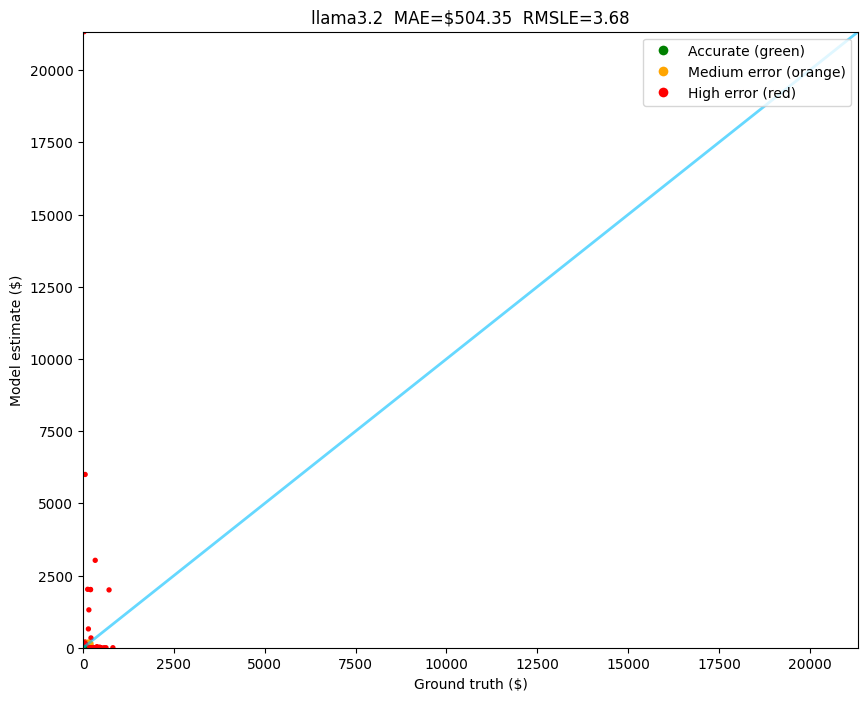


--- Evaluating qwen3-vl:4b ---


qwen3-vl:4b:   0%|          | 0/100 [00:00<?, ?it/s]

MAE=$143.90  RMSLE=4.58  Green hits=29/100 (29.0%)


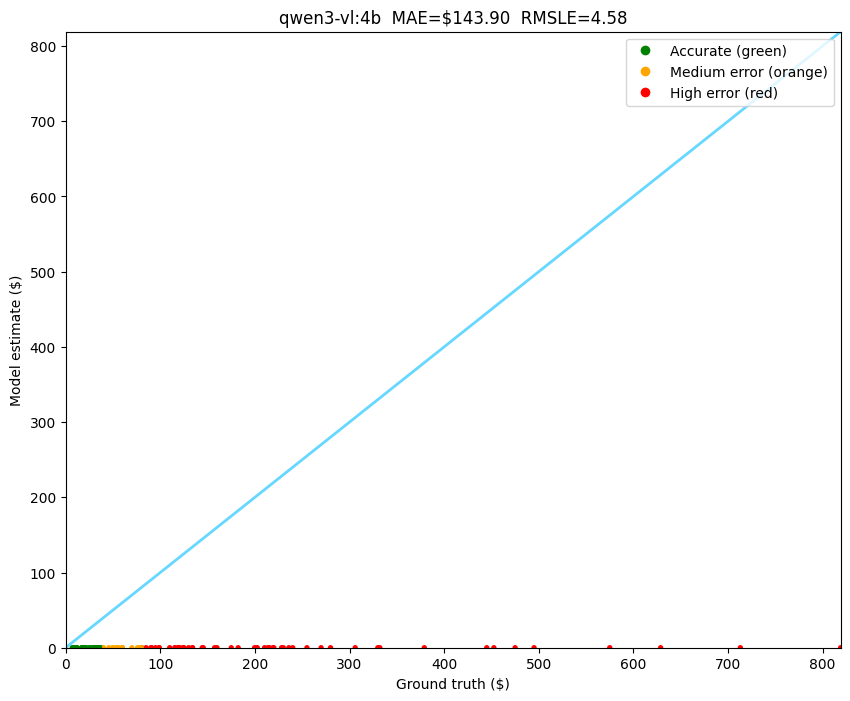

In [12]:
results = {}

for model_name in OPEN_SOURCE_MODELS:
    print(f"\n--- Evaluating {model_name} ---")
    guesses, truths, errors, sles, colors = evaluate_model(model_name, test, size=EVAL_SIZE)
    mae = sum(errors) / len(errors)
    rmsle = math.sqrt(sum(sles) / len(sles))
    hits = sum(1 for c in colors if c == "green")
    results[model_name] = {"mae": mae, "rmsle": rmsle, "hits_pct": 100 * hits / len(colors)}
    print(f"MAE=${mae:,.2f}  RMSLE={rmsle:,.2f}  Green hits={hits}/{len(colors)} ({results[model_name]["hits_pct"]:.1f}%)")
    chart_predictions(truths, guesses, colors, f"{model_name}  MAE=${mae:,.2f}  RMSLE={rmsle:,.2f}")

## Comparison table

In [ ]:
import pandas as pd

comparison = pd.DataFrame(results).T
comparison.index.name = "model"
comparison.round(2)

,mae,rmsle,hits_pct
model,,,
llama3.2,504.35,3.68,25.0
qwen3-vl:4b,143.90,4.58,29.0
